# Training YOLOv12

## 0. Hardware Summary

The following hardware was used for training and validation:

- **CPU:** AMD Ryzen 9 5950X - 16 Cores / 32 Threads
- **RAM:** 64 GB
- **GPU:** NVIDIA GeForce RTX 5070 Ti - 16 GB
- **CUDA:** Version 13.1


## 1. Setup

### i. Necessary Imports


In [ ]:
# For model
from ultralytics import YOLO, settings
import torch

# For visualization
import matplotlib.pyplot as plt

# For data handling
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # avoid kernel crash during training step
import zipfile

### ii. Monitoring

In [2]:
# Enable TensorBoard logging
settings.update({"tensorboard": True})

print('TensorBoard logging enabled.')
print('run "tensorboard --logdir=runs" to view logs.')


TensorBoard logging enabled.
run "tensorboard --logdir=runs" to view logs.


### iii. Loading the model

In [3]:
model = YOLO('yolo12l.pt') 

### iv. Ensure cuda availability

In [4]:
if torch.cuda.is_available():
    print(f'CUDA is available context device: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA is not available. Training will run on CPU.')

CUDA is available context device: NVIDIA GeForce RTX 5070 Ti


### v. Display dataset folder structure

In [21]:
# /F=show files, /A=use ASCII characters
output = !tree Dataset /F /A

# Print the output skipping the first 3 lines (Header/Path info)
print('Dataset/\n'+'\n'.join(output[3:]))

Dataset/
|   merged_images.zip
|   merged_input.json
|   
+---COCO-Format Annotations
|       COCO.json
|       COCO_condition.json
|       COCO_mounting.json
|       COCO_sign_shape.json
|       COCO_view_angle.json
|       
+---Individuals
|       images_Amy_Spiteri.zip
|       images_Daniel_Pace.zip
|       images_Ellyn_Rose_Debrincat.zip
|       images_Joachim_Grech.zip
|       input_Amy_Spiteri.json
|       input_Daniel_Pace.json
|       input_Ellyn_Rose_Debrincat.json
|       input_Joachim_Grech.json
|       
\---Train-Test-Val Split
    |   images.zip
    |   
    +---COCO-based
    |   +---COCO-based_COCO
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_condition
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_mounting
    |   |   \---annotation

### vi. Paths

In [19]:
DATASET_ROOT = './Dataset/Train-Test-Val Split'
YOLO_YAML_PATH = os.path.join(DATASET_ROOT, 'YOLO/YOLO_COCO/data.yaml')

# For unzipping images if needed
ZIP_PATH = os.path.join(DATASET_ROOT, 'images.zip')

### vii. Extract `images.zip` if necessary

In [20]:
# ensure destination is correct
if os.path.exists(DATASET_ROOT):
    
    # Check if the contents are already extracted
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_contents = zip_ref.namelist()
        
        # If there are contents in the zip file
        if zip_contents:
            item_path = os.path.join(DATASET_ROOT, zip_contents[0])
            
            # If the first item in the zip already exists in the extract path, skip extraction
            if os.path.exists(item_path):
                print(f'Contents already extracted to {DATASET_ROOT}. Skipping extraction.')
            
            # Else extract the contents
            else:
                print(f'Extracting {ZIP_PATH} to {DATASET_ROOT}...')
                zip_ref.extractall(DATASET_ROOT)
                print('Extraction complete.')
        else:
            print(f'Zip file {ZIP_PATH} is empty. No extraction performed.')

Extracting ./Dataset/Train-Test-Val Split\images.zip to ./Dataset/Train-Test-Val Split...
Extraction complete.


## 2. Training

In [8]:
model.train(
    data=YOLO_YAML_PATH,
    epochs=200,                                         # default
    batch=-1,                                           # autobatch 60% according to docs
    patience=20,                                        # early stopping after 20 epochs of no improvement
    device=0 if torch.cuda.is_available() else 'cpu',   # use GPU if available
    imgsz=640,                                          # default
    name='yolo12l_general_signs_earlystop',             # folder name for results
    save_period=10,                                     # save every 10 epochs
)

Ultralytics 8.3.252  Python-3.10.19 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./Dataset/Train-Test-Val Split\YOLO/YOLO_COCO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo12l_general_signs_earlystop, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

c:\Users\Daniel\miniconda3\envs\ARI3129\lib\site-packages\torch\jit\_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\Daniel\OneDrive\Desktop\Programs\Python\ari3129-cv-group-project\runs\detect\yolo12l_general_signs_earlystop
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      6.49G     0.8898      2.949      1.185         15        640: 100% ━━━━━━━━━━━━ 81/81 2.7it/s 29.6s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.9it/s 2.6s.1ss
                   all        111        174      0.185      0.261      0.158      0.121

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      6.93G      1.096      2.212      1.388         11        640: 100% ━━━━━━━━━━━━ 81/81 3.7it/s 21.8s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001E23646E440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

## 3. Testing & Evaluation

### i. Paths

In [ ]:
TEST_PATH = os.path.join(DATASET_ROOT, 'images', 'test')

### ii. Select model

In [14]:
test_model = YOLO(os.path.join('runs', 'detect', 'yolo12l_general_signs_earlystop', 'weights', 'best.pt'))

### iii. Display tests


0: 640x640 1 No Entry (One Way), 29.8ms
1: 640x640 (no detections), 29.8ms
2: 640x640 2 No Entry (One Way)s, 29.8ms
3: 640x640 1 Roundabout Ahead, 1 Stop, 29.8ms
4: 640x640 1 No Entry (One Way), 29.8ms
5: 640x640 1 Stop, 29.8ms
Speed: 4.2ms preprocess, 29.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


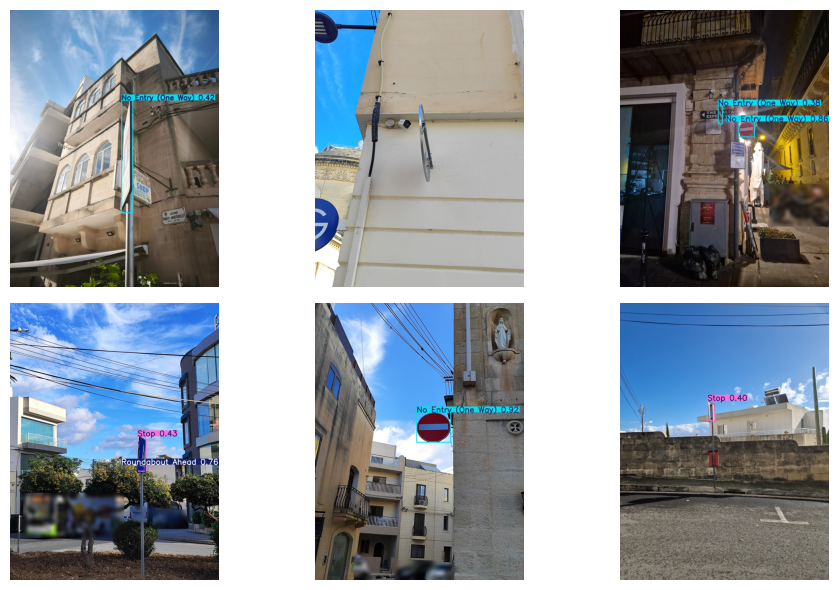

In [18]:
%matplotlib inline

# Get list of all image files in the test directory
test_images = [os.path.join(TEST_PATH, f) for f in os.listdir(TEST_PATH) if f.lower().endswith(('.jpg', '.jpeg', '.png'))] # ignore .heic bcoz icba

# Select first 6 images for a 2x3 grid
random_images = test_images[:6]

# Run inference on the selected images
results = test_model(random_images)

# Setup figure with specific size (makes images smaller/compact)
plt.figure(figsize=(10, 6))

# Display the results
for i, result in enumerate(results):
    img_array = result.plot()
    
    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    img_rgb = img_array[..., ::-1] # Reverse color channels

    # Create subplot: 2 rows, 3 columns, current index
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off') # Hide axis numbers

plt.tight_layout()
plt.show()
